# 37 — Fix downsample resolution

The segment masks (`02_segment_mask.png`) are **256×104** (WxH). The current downsample produces **51×40** (`out_w=51, out_h=40`, ~2040 px), bigger than we want. Retarget to **~800 px keeping the 256×104 aspect ratio**.

```
scale = sqrt(800 / (256*104)) = sqrt(800/26624) = 0.1733
width : 256 * 0.1733 = 44.4 -> 44   (out_w)
height: 104 * 0.1733 = 18.0 -> 18   (out_h)
-> 44 x 18 = 792 px,  aspect 44/18 = 2.44  (vs 256/104 = 2.46)
```

> **Source mask.** We re-downsample the *full-res* `02_segment_mask.png` (256×104), **not** the already-downsampled 51×40 mask (51→44 is `block_w = 51//44 = 1`, a crop with no averaging — wrong). The 256×104 mask is also what the 44×18 math is derived from.

> **One output → many samples.** Outputs are *shared*: every speaker capture of the same object/position symlinks the same `outputs/<output_id>/` artifacts (see `outputs/<id>/samples.jsonl`). So `sample_id != output_id`. `fix_downsample` therefore takes an **output_id**, re-downsamples the output once, then fans the metadata update + re-symlink out to **every** sample listed in that output's `samples.jsonl`. Updating only `samples/<output_id>` would leave the sibling samples' `metadata.jsonl` stale (`out_h=40, out_w=51`) while their `y.npy` symlink already resolves to the new mask.

Per output, this updates in `outputs/<output_id>/` **and** each linked `samples/<sample_id>/`:
- `03_downsampled_segment_mask.png` — new 44×18 mask (output dir; samples symlink it)
- `y.npy` — new (18, 44) float mask in [0, 1]
- `04_com.jsonl` — `com` unchanged, `downsampled_com` recomputed on the new mask
- `metadata.jsonl` — `out_h`, `out_w`, `downsampled_com` (in both output and every sample)
- re-establishes each sample→output symlink (`y.npy`, `outputs/03...`, `outputs/04_com.jsonl`)

Unaffected: `00/01/02` images, `05_overhead.png` (built from the full-res mask + `com`, not the downsampled mask), and `com`.

In [1]:
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src3"))
from overhead_pipeline import downsample, center_of_mass
from io_utils import load, save, symlink, preview_image

DATA_DIR = Path(r"D:\eturok\experiment-22\data")
NEW_OUT_H, NEW_OUT_W = 18, 44  # (H, W): ~800 px, keeps the 256x104 segment-mask aspect

FIXED_SAMPLE_IDS = []  # every fix_downsample(do_save=True) call appends the sample ids it updated

In [2]:
def update_metadata_keys(path: Path, updates: dict, do_save: bool = True):
    """metadata.jsonl is one single-key dict per line. Overwrite the lines whose key is in
    `updates`; append any keys that weren't already present. Leaves all other lines intact."""
    if not do_save:
        return
    rows = load(path)  # list[dict]
    seen = set()
    for row in rows:
        for k in row:
            if k in updates:
                row[k] = updates[k]
                seen.add(k)
    for k, v in updates.items():
        if k not in seen:
            rows.append({k: v})
    save(rows, path)


def fix_downsample(output_id: str, data_dir: Path = DATA_DIR, out_h: int = NEW_OUT_H, out_w: int = NEW_OUT_W, do_save: bool = True):
    """Re-downsample one shared OUTPUT's segment mask to (out_h, out_w), then propagate to
    every sample that references it. Idempotent — safe to re-run."""
    output_dir = data_dir / "outputs" / output_id

    meta = {k: v for d in load(output_dir / "metadata.jsonl") for k, v in d.items()}
    is_empty_box = bool(meta.get("is_empty_box", False))

    # 1. re-downsample the FULL-RES segment mask (256x104) -> (out_h, out_w)
    segment_mask = load(output_dir / "02_segment_mask.png")
    downsampled_mask = downsample(segment_mask, out_h, out_w)
    save(downsampled_mask, output_dir / "03_downsampled_segment_mask.png", do_save)

    # 2. y.npy: float mask in [0, 1]
    y = np.array(downsampled_mask, dtype=np.float32) / 255.0
    save(y, output_dir / "y.npy", do_save)

    # 3. recompute downsampled_com on the new mask (com on the full mask is unchanged)
    com = load(output_dir / "04_com.jsonl")[0]["com"]
    downsampled_com = (-1, -1) if is_empty_box else center_of_mass(downsampled_mask)
    save({"com": com, "downsampled_com": downsampled_com}, output_dir / "04_com.jsonl", do_save)

    # 4. update the output's metadata
    updates = {"out_h": out_h, "out_w": out_w, "downsampled_com": list(downsampled_com)}
    update_metadata_keys(output_dir / "metadata.jsonl", updates, do_save)

    # 5. fan out to EVERY sample sharing this output: update metadata + re-symlink
    sample_ids = sorted({r["sample_id"] for r in load(output_dir / "samples.jsonl") if "sample_id" in r})
    for sid in sample_ids:
        sample_dir = data_dir / "samples" / sid
        update_metadata_keys(sample_dir / "metadata.jsonl", updates, do_save)
        symlink(output_dir / "y.npy", sample_dir / "y.npy", do_save)
        symlink(output_dir / "03_downsampled_segment_mask.png", sample_dir / "outputs/03_downsampled_segment_mask.png", do_save)
        symlink(output_dir / "04_com.jsonl", sample_dir / "outputs/04_com.jsonl", do_save)

    # record what we actually fixed (only real writes) so we can audit coverage at the end
    if do_save:
        FIXED_SAMPLE_IDS.extend(sample_ids)

    print(f"[output {output_id}] y -> {y.shape} (H,W)  out_h={out_h} out_w={out_w}  "
          f"downsampled_com={tuple(round(c, 2) for c in downsampled_com)}  "
          f"| updated {len(sample_ids)} sample(s): {sample_ids}")
    return y, downsampled_com

## Dry-run preview on one output (does not write)

`do_save=False` only computes/inspects the new mask; it does not touch disk or fan out to samples.

[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(12.64, 11.93)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']
new y shape (H,W): (18, 44) | sum: 74.58 | downsampled_com: (12.63531229197919, 11.927178304329441)


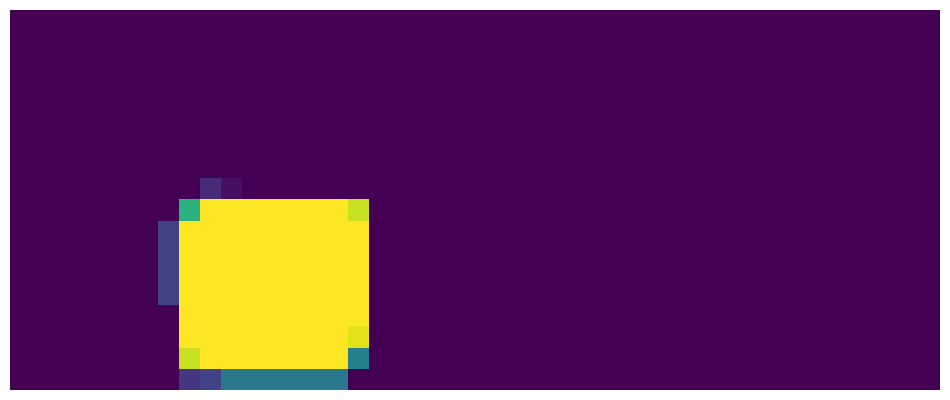

In [3]:
y, dcom = fix_downsample("000000", do_save=False)
print("new y shape (H,W):", y.shape, "| sum:", round(float(y.sum()), 2), "| downsampled_com:", dcom)
preview_image((y * 255).astype(np.uint8))

## Run for real on one output

Re-running is idempotent. Do this on `000000` first to also repair its sibling samples (`000001`–`000007`) that an earlier single-sample run left with stale metadata.

In [4]:
_ = fix_downsample("000000", do_save=True)

[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(12.64, 11.93)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']


## Run for every output

Iterates over **output** ids (each fans out to all its samples). Only run once your recovery/processing jobs on these files have finished.

In [5]:
FIXED_SAMPLE_IDS.clear()  # fresh accounting for this full pass
output_ids = sorted(p.name for p in (DATA_DIR / "outputs").iterdir() if p.is_dir())
print(f"{len(output_ids)} outputs")
for oid in output_ids:
    fix_downsample(oid, do_save=True)

86 outputs
[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(12.64, 11.93)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']
[output 000001] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.05, 11.99)  | updated 8 sample(s): ['000008', '000009', '000010', '000011', '000012', '000013', '000014', '000015']
[output 000002] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(5.08, 11.96)  | updated 8 sample(s): ['000016', '000017', '000018', '000019', '000020', '000021', '000022', '000023']
[output 000003] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(12.49, 15.54)  | updated 8 sample(s): ['000024', '000025', '000026', '000027', '000028', '000029', '000030', '000031']
[output 000004] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.46, 15.31)  | updated 8 sample(s): ['000032', '000033', '000034', '000035', '000036', '000037', '000038', '000039']
[output 000005] y -> (18, 44) (H

## Audit — did we fix every sample?

Compares the accumulated `FIXED_SAMPLE_IDS` against every sample dir on disk and reports anything missed.

In [6]:
all_sample_ids = sorted(p.name for p in (DATA_DIR / "samples").iterdir() if p.is_dir())
fixed = set(FIXED_SAMPLE_IDS)

missing = [s for s in all_sample_ids if s not in fixed]          # on disk but never fixed
orphans = sorted(fixed - set(all_sample_ids))                    # fixed but no sample dir on disk
dupes = sorted({s for s in FIXED_SAMPLE_IDS if FIXED_SAMPLE_IDS.count(s) > 1})  # fixed >1x

print(f"samples on disk    : {len(all_sample_ids)}")
print(f"fixed (calls)      : {len(FIXED_SAMPLE_IDS)}")
print(f"fixed (unique)     : {len(fixed)}")
print(f"missing (not fixed): {len(missing)}  {missing}")
if orphans: print(f"fixed but no dir   : {orphans}")
if dupes:   print(f"fixed more than once: {dupes}")
print("\n" + ("✅ every sample fixed" if not missing else f"❌ {len(missing)} sample(s) NOT fixed"))

samples on disk    : 688
fixed (calls)      : 688
fixed (unique)     : 688
missing (not fixed): 0  []

✅ every sample fixed


## Visual sanity check

For one `sample_id`, show the pipeline side by side: resized overhead → full-res segment mask → downsampled mask → the saved `y.npy`.

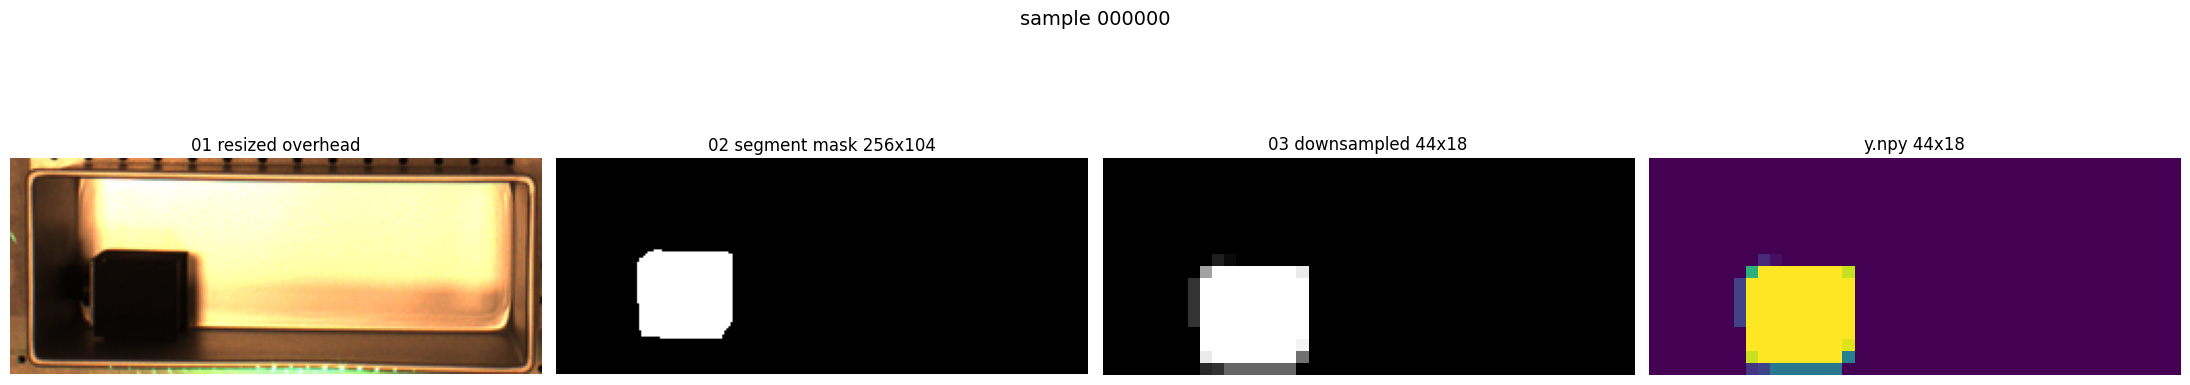

In [7]:
import matplotlib.pyplot as plt


def sanity_check(sample_id: str, data_dir: Path = DATA_DIR):
    sd = data_dir / "samples" / sample_id
    resized = np.array(load(sd / "outputs/01_resized_overhead.png"))
    seg = np.array(load(sd / "outputs/02_segment_mask.png"))
    down = np.array(load(sd / "outputs/03_downsampled_segment_mask.png"))
    y = np.load(sd / "y.npy")

    # left -> right = pipeline order: overhead -> segment -> downsample -> saved y
    panels = [
        ("01 resized overhead", resized, None),
        (f"02 segment mask {seg.shape[1]}x{seg.shape[0]}", seg, "gray"),
        (f"03 downsampled {down.shape[1]}x{down.shape[0]}", down, "gray"),
        (f"y.npy {y.shape[1]}x{y.shape[0]}", y, "viridis"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1 if cmap == "viridis" else None)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"sample {sample_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


sanity_check("000000")